In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

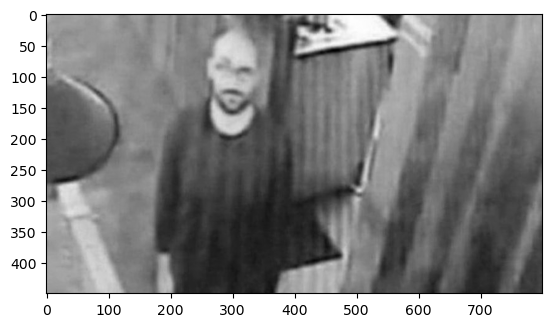

In [3]:
img1 = plt.imread('backup.jpg')
plt.imshow(img1)

img_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')



(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

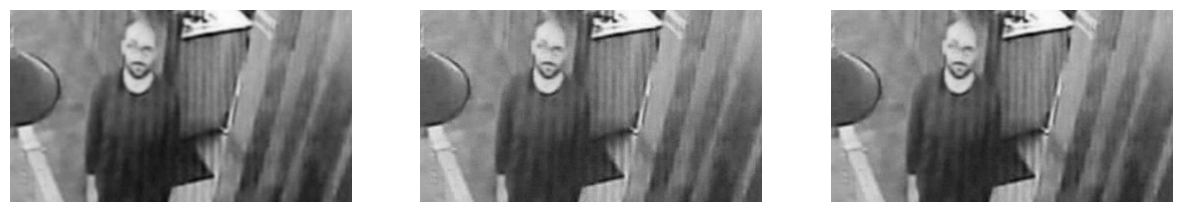

In [4]:
kernelSmoothing = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

kernelSharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

smoothing = cv2.filter2D(img_gray, -1, kernelSmoothing)
sharpening = cv2.filter2D(img_gray, -1, kernelSharpening)
smoothing_sharpening = cv2.filter2D(smoothing, -1, kernelSharpening)


plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(smoothing, cmap= 'gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpening, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smoothing_sharpening, cmap='gray')
plt.axis('off')

In [ ]:
def filter(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # Tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            # filter rata-rata / mean filter
            area = size * size
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus mean manual / manual mean formula
                    # BUAT RUMUS SENDIRI / MAKE YOUR OWN FORMULA
                    
        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    # BUAT RUMUS SENDIRI / MAKE YOUR OWN FORMULA
                    
        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                            
                    # cari nilai terbanyak / find mode value
                    max_count = -1
                    mode_val = -1
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
                    
    # kembalikan gambar / return image
    return canvas

# cara panggil / how to call
# hasil = filter(fotoTania, 3, 'mean')

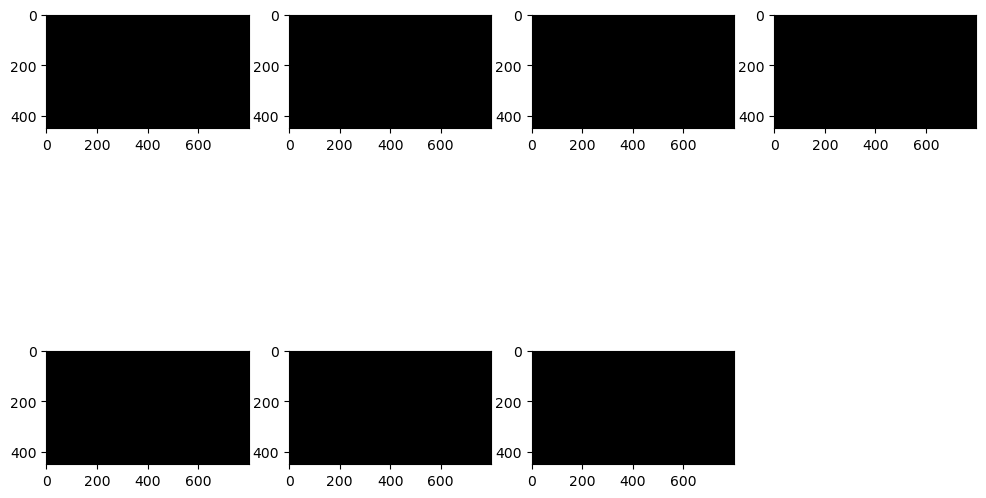

In [14]:
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

RobertsX = np.array([
    [-1, 0],
    [0, -1]
], dtype=np.float32)

RobertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

prewitt_modus_3x3 = filter(img_gray, 2, "Modus")
plt.figure(figsize=(12,8))
plt.subplot(2,4,1)
plt.imshow(prewitt_modus_3x3, cmap='gray')

sobel_modus_9x9 = filter(img_gray, 2, "sobel")
plt.subplot(2,4,2)
plt.imshow(sobel_modus_9x9, cmap='gray')

roberts_mean_3x3 = filter(img_gray, 1, "roberts")
plt.subplot(2,4,3)
plt.imshow(roberts_mean_3x3, cmap='gray')

sobel_prewitt = cv2.filter2D(sobel_modus_9x9, -1, prewitt_modus_3x3)
plt.subplot(2,4,4)
plt.imshow(sobel_prewitt, cmap='gray')

sobel_prewitt = cv2.filter2D(roberts_mean_3x3, -1, prewitt_modus_3x3)
plt.subplot(2,4,5)
plt.imshow(sobel_prewitt, cmap='gray')

sobel_prewitt = cv2.filter2D(roberts_mean_3x3, -1, sobel_modus_9x9)
plt.subplot(2,4,6)
plt.imshow(sobel_prewitt, cmap='gray')

sobel_prewitt = cv2.filter2D(roberts_mean_3x3, -1, sobel_modus_9x9,  prewitt_modus_3x3)
plt.subplot(2,4,7)
plt.imshow(sobel_prewitt, cmap='gray')

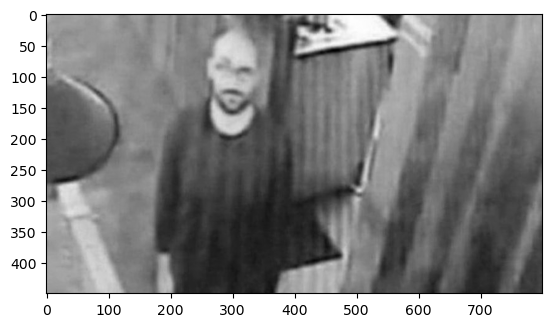

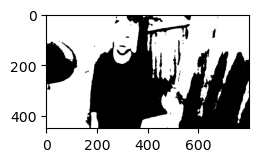

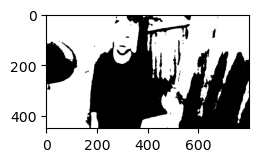

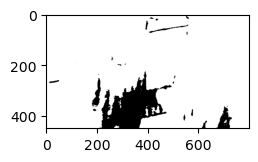

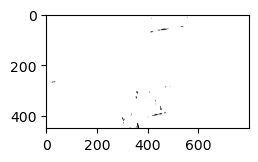

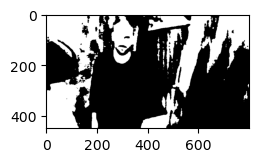

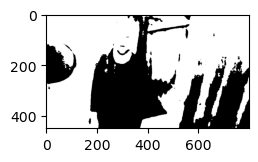

In [ ]:
img_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')

threshold = 120
hasil_thresh1 = np.zeros_like(img_gray)         
hasil_thresh1[img_gray >= threshold] = 255       
hasil_thresh1[img_gray <  threshold] = 0 

plt.figure(figsize=(12,8))
plt.subplot(2,4,1)
plt.imshow(hasil_thresh1, cmap='gray')

threshold = 80
hasil_thresh2 = np.zeros_like(img_gray)         
hasil_thresh2[img_gray >= threshold] = 255       
hasil_thresh2[img_gray <  threshold] = 0 

plt.figure(figsize=(12,8))
plt.subplot(2,4,2)
plt.imshow(hasil_thresh1, cmap='gray')

threshold = 60
hasil_thresh3 = np.zeros_like(img_gray)         
hasil_thresh3[img_gray >= threshold] = 255       
hasil_thresh3[img_gray <  threshold] = 0 

plt.figure(figsize=(12,8))
plt.subplot(2,4,2)
plt.imshow(hasil_thresh3, cmap='gray')

threshold = 40
hasil_thresh4 = np.zeros_like(img_gray)         
hasil_thresh4[img_gray >= threshold] = 255       
hasil_thresh4[img_gray <  threshold] = 0 

plt.figure(figsize=(12,8))
plt.subplot(2,4,2)
plt.imshow(hasil_thresh4, cmap='gray')

threshold = 140
hasil_thresh5 = np.zeros_like(img_gray)         
hasil_thresh5[img_gray >= threshold] = 255       
hasil_thresh5[img_gray <  threshold] = 0 

plt.figure(figsize=(12,8))
plt.subplot(2,4,2)
plt.imshow(hasil_thresh5, cmap='gray')

threshold = 106
hasil_thresh6 = np.zeros_like(img_gray)         
hasil_thresh6[img_gray >= threshold] = 255       
hasil_thresh6[img_gray <  threshold] = 0 

plt.figure(figsize=(12,8))
plt.subplot(2,4,2)
plt.imshow(hasil_thresh6, cmap='gray')